# DATA-445 In-Class Assignment 3

Consider the `framingham.csv` data file. The dataset is publicly available on the Kaggle website, and it is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts. The classification goal is to predict whether the patient has 10-year risk of future coronary heart disease (CHD). The dataset provides the patients' information. It includes over 4,000 records and 15 attributes. Each attribute is a potential risk factor. There are demographic, behavioral, and medical risk factors.

- **Demographic:**
  - Sex: male or female (Nominal)
  - Age: Age of the patient (Continuous)
- **Behavioral:**
  - Current Smoker: whether or not the patient is a current smoker (Nominal)
  - Cigs Per Day: the number of cigarettes that the person smoked on average in one day (Continuous)
- **Medical (history):**
  - BP Meds: whether or not the patient was on blood pressure medication (Nominal)
  - Prevalent Stroke: whether or not the patient had previously had a stroke (Nominal)
  - Prevalent Hyp: whether or not the patient was hypertensive (Nominal)
  - Diabetes: whether or not the patient had diabetes (Nominal)
- **Medical (current):**
  - Tot Chol: total cholesterol level (Continuous)
  - Sys BP: systolic blood pressure (Continuous)
  - Dia BP: diastolic blood pressure (Continuous)
  - BMI: Body Mass Index (Continuous)
  - Heart Rate: heart rate (Continuous)
  - Glucose: glucose level (Continuous)
- **Predict variable (desired target):**
  - 10 year risk of coronary heart disease CHD (binary: "1" means "Yes", "0" means "No")

## 1. (3 points) Using the pandas library, read the csv data file and create a data-frame called `heart`.

In [15]:
import pandas as pd

heart = pd.read_csv("framingham.csv")
heart.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 2. (3 points) Remove observations with missing values.

In [16]:
heart = heart.dropna()
heart.shape

(3656, 16)

## 3. (4 points) Create a scatter plot of `BMI` and `heartRate`. Describe the plot.

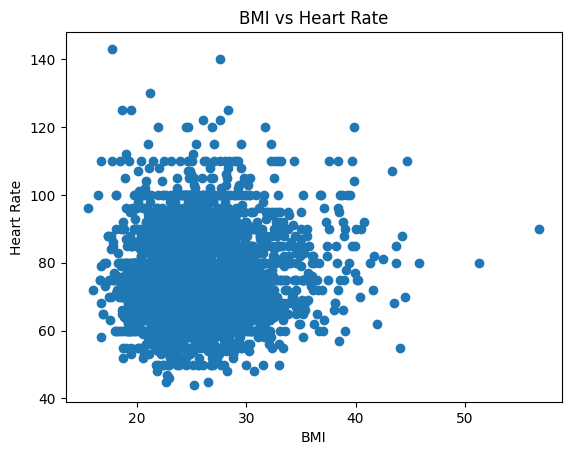

In [17]:
import matplotlib.pyplot as plt

plt.plot(heart["BMI"], heart["heartRate"], 'o')
plt.title("BMI vs Heart Rate")
plt.xlabel("BMI")
plt.ylabel("Heart Rate")
plt.show()

There is no real relationship showing that the higher BMI means the higher the heart rate

## 4. (4 points) Create a scatter plot of `glucose` and `BMI`. Describe the plot.

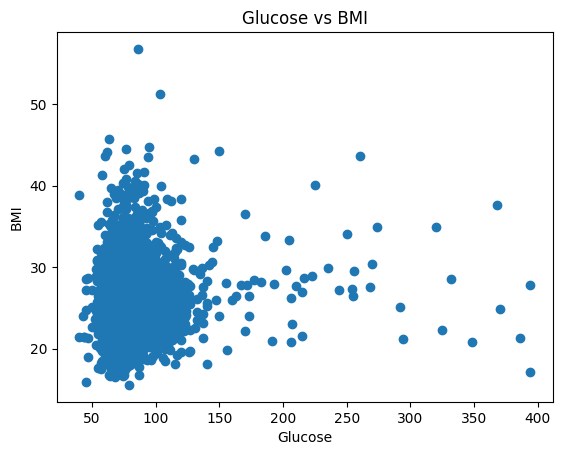

In [18]:
plt.plot(heart["glucose"], heart["BMI"], 'o')
plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

There is no relationship between Glucose and BMI, the more glucose does not mean higher BMI.

## 5. (5 points) Build a logistic regression model in which: `age`, `currentSmoker`, `totChol`, `BMI`, and `heartRate` are the predictor variables, and `TenYearCHD` is the target variable.

In [22]:
from sklearn.linear_model import LogisticRegression

X=heart[["age", "currentSmoker", "totChol", "BMI", "heartRate"]]
Y =heart["TenYearCHD"]

model = LogisticRegression()
model.fit(X, Y)

LogisticRegression()

## 6. (3 points) Using the model from part 5, predict the likelihood of risk of coronary disease of a patient with the following characteristics: `age = 50`, `currentSmoker = 1`, `totChol = 250`, `BMI = 27`, and `heartRate = 85`.

In [23]:
# Defining a new patient's data for prediction
new_df = pd.DataFrame({
    "age": [50],
    "currentSmoker": [1],
    "totChol": [250],
    "BMI": [27],
    "heartRate": [85]
})

# Predicting the risk of heart disease for the new patient
prediction = model.predict_proba(new_df)
prediction

array([[0.81930797, 0.18069203]])